In [1]:
import pandas as pd
import argparse
import numpy as np
import pymc as pm
import arviz as az
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import ajr_causalpy_iv as ajr
import ajr_causalpy_iv_priorfac as ajr_priorfac
import pytensor



%load_ext autoreload
%autoreload 2

path = r"C:\Users\B375471\Downloads\Acemoglu_osv\Data\qog_std_cs_jan25.csv"
df = pd.read_csv(path)

non_missing = df['ajr_settmort'].notna().sum()
total_rows  = len(df)

print(f"Non‑missing settler mortality observations: {non_missing}")
print(f"Total rows in file: {total_rows}")



Non‑missing settler mortality observations: 86
Total rows in file: 194


In [2]:


# Load the data
data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df_ajr = ajr.load_ajr_data(data_path, baseline_only=True)


# Run the model with pre-processed data
iv = ajr.run(
    data=df_ajr,  # Pass the filtered dataframe 
    priors=None, 
    draws=2000, 
    tune=1000, 
    chains=4, 
    cores=4, 
    covariates=None,
    netcdf_path="ajr_iv_posterior.nc"
)

Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when co

Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 84 seconds.
Sampling: [likelihood]
Sampling: [likelihood]


Output()

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_z[Intercept]  2.187  0.658   0.912    3.401      0.015    0.010   
beta_z[avexpr]     0.902  0.100   0.706    1.083      0.002    0.002   
beta_t[Intercept]  9.438  0.462   8.600   10.333      0.009    0.006   
beta_t[logem4]    -0.628  0.095  -0.800   -0.446      0.002    0.001   

                   ess_bulk  ess_tail  r_hat  
beta_z[Intercept]  1955.998  2123.897  1.002  
beta_z[avexpr]     1926.030  2135.286  1.002  
beta_t[Intercept]  2616.979  3475.379  1.001  
beta_t[logem4]     2580.899  3372.523  1.001  

Posterior + PPC saved to → ajr_iv_posterior.nc


In [3]:
ajr.get_available_covariates(data=df_ajr)

['africa', 'asia', 'lat_abst', 'loghjypl', 'other_cont', 'rich4']

array([<Axes: title={'center': 'beta_z\nIntercept'}>,
       <Axes: title={'center': 'beta_z\navexpr'}>], dtype=object)

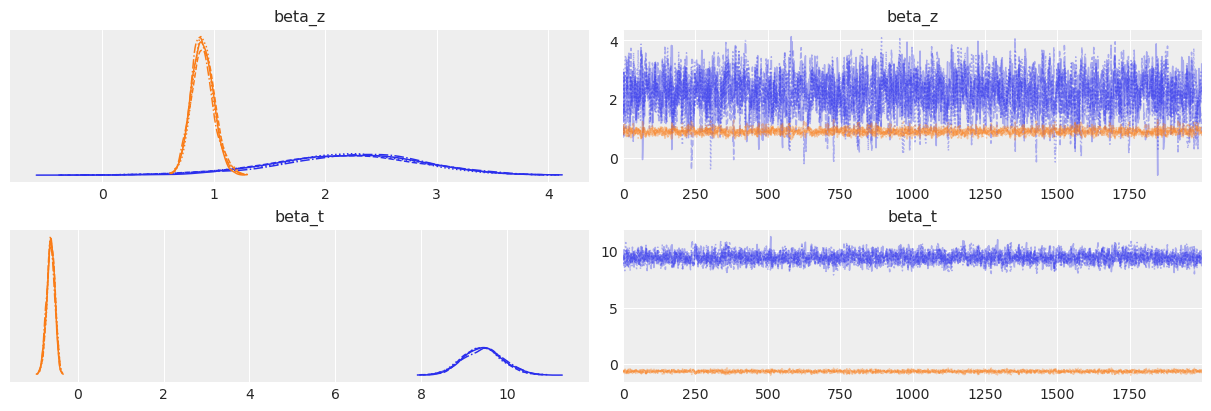

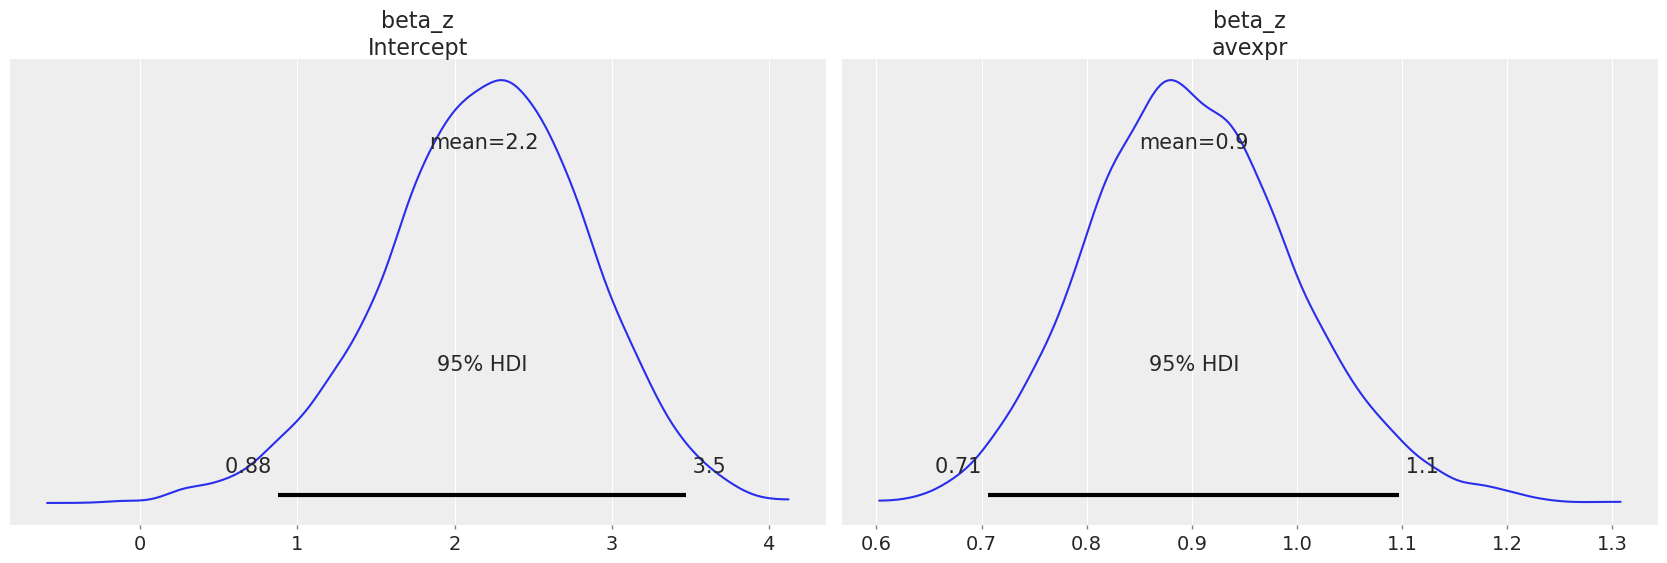

In [4]:
idata = az.from_netcdf("ajr_iv_posterior.nc")
az.plot_trace(idata, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata, var_names=["beta_z"], hdi_prob=0.95)


Shape check - first_stage_preds: (4, 2000, 64), observed_avexpr: (64,)
Instrument relevance (logem4 vs avexpr): -0.520
Rule of thumb: Should be > 0.3 for reasonable instrument strength
First-stage R-squared: -0.135
Fitted vs observed correlation: 1.000 (should be high)
First-stage R-squared: -0.135
Fitted vs observed correlation: 1.000 (should be high)


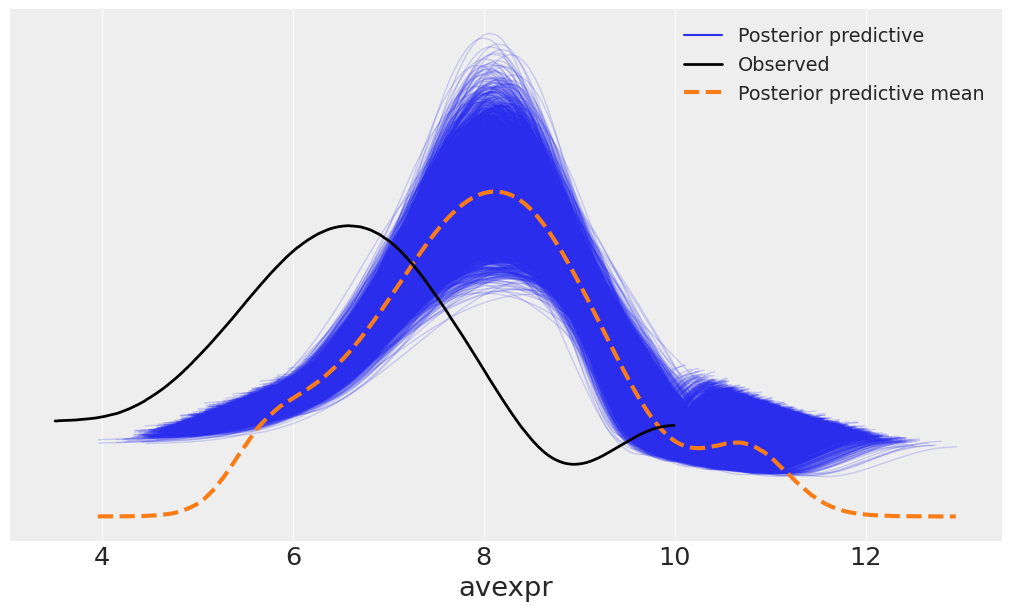

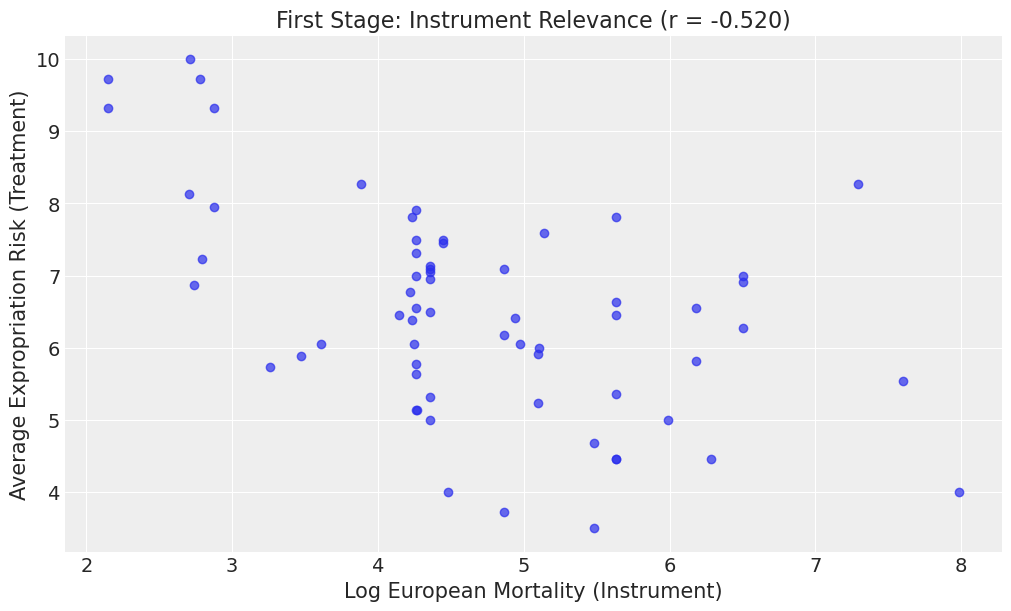

In [ ]:
# Check instrument relevance - first stage correlation between instrument and treatment
import xarray as xr

# Use the same filtered data from above
first_stage_preds = idata.posterior['mu'].isel(mu_dim_1=0)  # First stage predictions
observed_avexpr = df_ajr['avexpr'].values

print(f"Shape check - first_stage_preds: {first_stage_preds.shape}, observed_avexpr: {observed_avexpr.shape}")

# CORRECT instrument relevance check: correlation between instrument (logem4) and treatment (avexpr)
instrument_treatment_corr = np.corrcoef(df_ajr['logem4'], df_ajr['avexpr'])[0,1]
print(f"Instrument relevance (logem4 vs avexpr): {instrument_treatment_corr:.3f}")
print("Rule of thumb: Should be > 0.3 for reasonable instrument strength")

# First-stage model fit: how well does the model predict avexpr?
if first_stage_preds.shape[2] == len(observed_avexpr):
    # Add first-stage PPC for visualization
    idata.posterior_predictive = idata.posterior_predictive.assign(
        avexpr=first_stage_preds.rename(mu_dim_0='avexpr_dim_0')
    )
    observed_avexpr_da = xr.DataArray(
        observed_avexpr, 
        dims=['avexpr_dim_0'],
        coords={'avexpr_dim_0': range(len(observed_avexpr))}
    )
    idata.observed_data = idata.observed_data.assign(avexpr=observed_avexpr_da)

    # Plot first-stage fit
    az.plot_ppc(idata, data_pairs={"avexpr": "avexpr"}, var_names=["avexpr"], figsize=(10, 6))
    
    # Model fit metrics (R-squared equivalent)
    pred_mean = first_stage_preds.mean(['chain', 'draw'])
    ss_res = np.sum((observed_avexpr - pred_mean)**2)
    ss_tot = np.sum((observed_avexpr - np.mean(observed_avexpr))**2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"First-stage R-squared: {r_squared:.3f}")
    
    
else:
    print("ERROR: Dimension mismatch!")
    print(f"Model predictions: {first_stage_preds.shape[2]}, Data observations: {len(observed_avexpr)}")

# Additional instrument relevance plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df_ajr['logem4'], df_ajr['avexpr'], alpha=0.7)
plt.xlabel('Log European Mortality (Instrument)')
plt.ylabel('Average Expropriation Risk (Treatment)')
plt.title(f'First Stage: Instrument Relevance (r = {instrument_treatment_corr:.3f})')
plt.show()

In [9]:
# Compare IV estimate with OLS (should differ if endogeneity exists)
ols_model = smf.ols('logpgp95 ~ avexpr', data=df_ajr).fit()
iv_effect = beta_z_samples.sel(covariates='Intercept')  # Causal effect from IV

print(f"OLS estimate: {ols_model.params['avexpr']:.3f}")
print(f"IV estimate (median): {iv_effect.median():.3f}")
print(f"IV estimate (95% HDI): [{iv_effect.quantile(0.025):.3f}, {iv_effect.quantile(0.975):.3f}]")

OLS estimate: 0.522
IV estimate (median): 2.215
IV estimate (95% HDI): [0.802, 3.401]


Computing correlations for 8000 posterior samples...

=== BAYESIAN EXCLUSION RESTRICTION TEST ===
Posterior median correlation: 0.089
95% HDI: [-0.202, 0.383]
HDI contains zero: True
✓ PASS: Cannot reject exclusion restriction (HDI contains 0)


C:\Users\B375471\AppData\Local\Temp\ipykernel_23744\2327672217.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


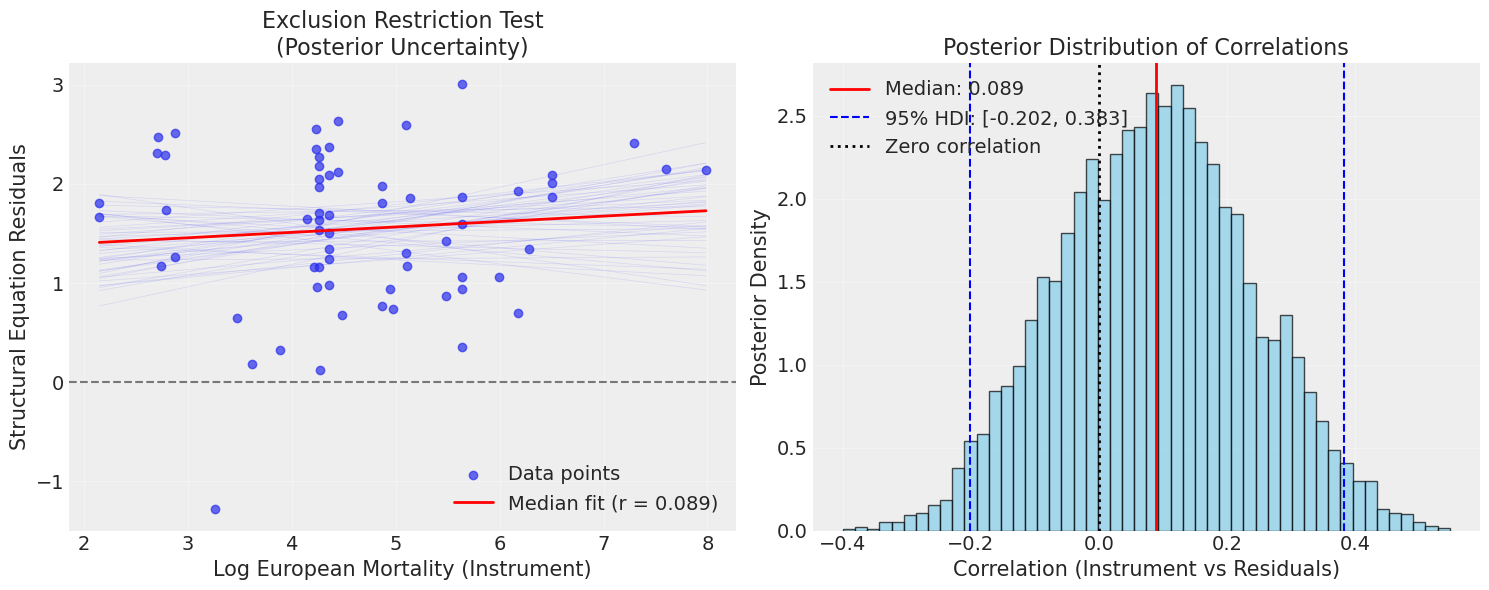


Interpretation:
✓ STRONG SUPPORT: Low correlation and HDI contains 0

Diagnostic Information:
Standard deviation of posterior correlations: 0.1508
Range of correlations: [-0.400, 0.548]


In [25]:
# Check if residuals from both equations are uncorrelated with instrument
# This tests the exclusion restriction using BAYESIAN POSTERIOR SAMPLES
import xarray as xr

# Use the same filtered data and predictions from previous cells
first_stage_preds = idata.posterior['mu'].isel(mu_dim_1=0)  # First stage (avexpr) predictions
structural_preds = idata.posterior['mu'].isel(mu_dim_1=1)  # Structural (logpgp95) predictions

# Calculate residuals for each posterior sample
observed_logpgp95 = df_ajr['logpgp95'].values
observed_logem4 = df_ajr['logem4'].values

# Calculate correlations for each posterior sample
n_chains, n_draws, n_obs = structural_preds.shape
correlations_posterior = []

print(f"Computing correlations for {n_chains * n_draws} posterior samples...")

for chain in range(n_chains):
    for draw in range(n_draws):
        # Get residuals for this posterior sample
        pred_logpgp95 = structural_preds[chain, draw, :].values
        residuals = observed_logpgp95 - pred_logpgp95
        
        # Calculate correlation between instrument and residuals
        corr = np.corrcoef(observed_logem4, residuals)[0, 1]
        correlations_posterior.append(corr)

correlations_posterior = np.array(correlations_posterior)

# Calculate HDI from posterior samples
hdi_lower = np.percentile(correlations_posterior, 2.5)
hdi_upper = np.percentile(correlations_posterior, 97.5)
corr_median = np.median(correlations_posterior)

print(f"\n=== BAYESIAN EXCLUSION RESTRICTION TEST ===")
print(f"Posterior median correlation: {corr_median:.3f}")
print(f"95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]")

# Test if HDI contains zero
contains_zero = hdi_lower <= 0 <= hdi_upper
print(f"HDI contains zero: {contains_zero}")

if contains_zero:
    print("✓ PASS: Cannot reject exclusion restriction (HDI contains 0)")
else:
    print("✗ FAIL: Evidence against exclusion restriction (HDI excludes 0)")

# Visualization using posterior samples
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Scatter with median residuals
median_residuals = observed_logpgp95 - structural_preds.mean(['chain', 'draw']).values
ax1.scatter(observed_logem4, median_residuals, alpha=0.7, label='Data points')

# Show uncertainty with individual posterior samples (subsample for clarity)
n_sample_lines = 50
sample_indices = np.random.choice(len(correlations_posterior), n_sample_lines, replace=False)

for i, idx in enumerate(sample_indices):
    chain_idx = idx // n_draws
    draw_idx = idx % n_draws
    
    pred_sample = structural_preds[chain_idx, draw_idx, :].values
    residuals_sample = observed_logpgp95 - pred_sample
    
    # Fit line for this sample
    slope, intercept = np.polyfit(observed_logem4, residuals_sample, 1)
    line_x = np.linspace(observed_logem4.min(), observed_logem4.max(), 100)
    line_y = slope * line_x + intercept
    
    ax1.plot(line_x, line_y, 'blue', alpha=0.1, linewidth=0.5)

# Overall median line
median_slope, median_intercept = np.polyfit(observed_logem4, median_residuals, 1)
line_x = np.linspace(observed_logem4.min(), observed_logem4.max(), 100)
median_line_y = median_slope * line_x + median_intercept
ax1.plot(line_x, median_line_y, 'red', linewidth=2, label=f'Median fit (r = {corr_median:.3f})')

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Log European Mortality (Instrument)')
ax1.set_ylabel('Structural Equation Residuals')
ax1.set_title('Exclusion Restriction Test\n(Posterior Uncertainty)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Posterior distribution of correlations
ax2.hist(correlations_posterior, bins=50, alpha=0.7, density=True, color='skyblue', edgecolor='black')
ax2.axvline(corr_median, color='red', linestyle='-', linewidth=2, label=f'Median: {corr_median:.3f}')
ax2.axvline(hdi_lower, color='blue', linestyle='--', label=f'95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]')
ax2.axvline(hdi_upper, color='blue', linestyle='--')
ax2.axvline(0, color='black', linestyle=':', linewidth=2, label='Zero correlation')
ax2.set_xlabel('Correlation (Instrument vs Residuals)')
ax2.set_ylabel('Posterior Density')
ax2.set_title('Posterior Distribution of Correlations')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary assessment
print(f"\nInterpretation:")
if abs(corr_median) < 0.1 and contains_zero:
    print("✓ STRONG SUPPORT: Low correlation and HDI contains 0")
elif abs(corr_median) < 0.2 and contains_zero:
    print("✓ MODERATE SUPPORT: Modest correlation but HDI contains 0")
elif contains_zero:
    print("⚠ WEAK SUPPORT: High correlation but HDI still contains 0")
else:
    print("✗ NO SUPPORT: Correlation significantly different from 0")

# Additional diagnostic: Show how much uncertainty comes from posterior vs sampling
print(f"\nDiagnostic Information:")
print(f"Standard deviation of posterior correlations: {np.std(correlations_posterior):.4f}")
print(f"Range of correlations: [{np.min(correlations_posterior):.3f}, {np.max(correlations_posterior):.3f}]")

array([[<Axes: ylabel='beta_t\nIntercept'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='beta_t\nlogem4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='beta_z\nIntercept'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='beta_z\navexpr'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='beta_t\nIntercept', ylabel='rho'>,
        <Axes: xlabel='beta_t\nlogem4'>,
        <Axes: xlabel='beta_z\nIntercept'>,
        <Axes: xlabel='beta_z\navexpr'>, <Axes: xlabel='rho'>]],
      dtype=object)

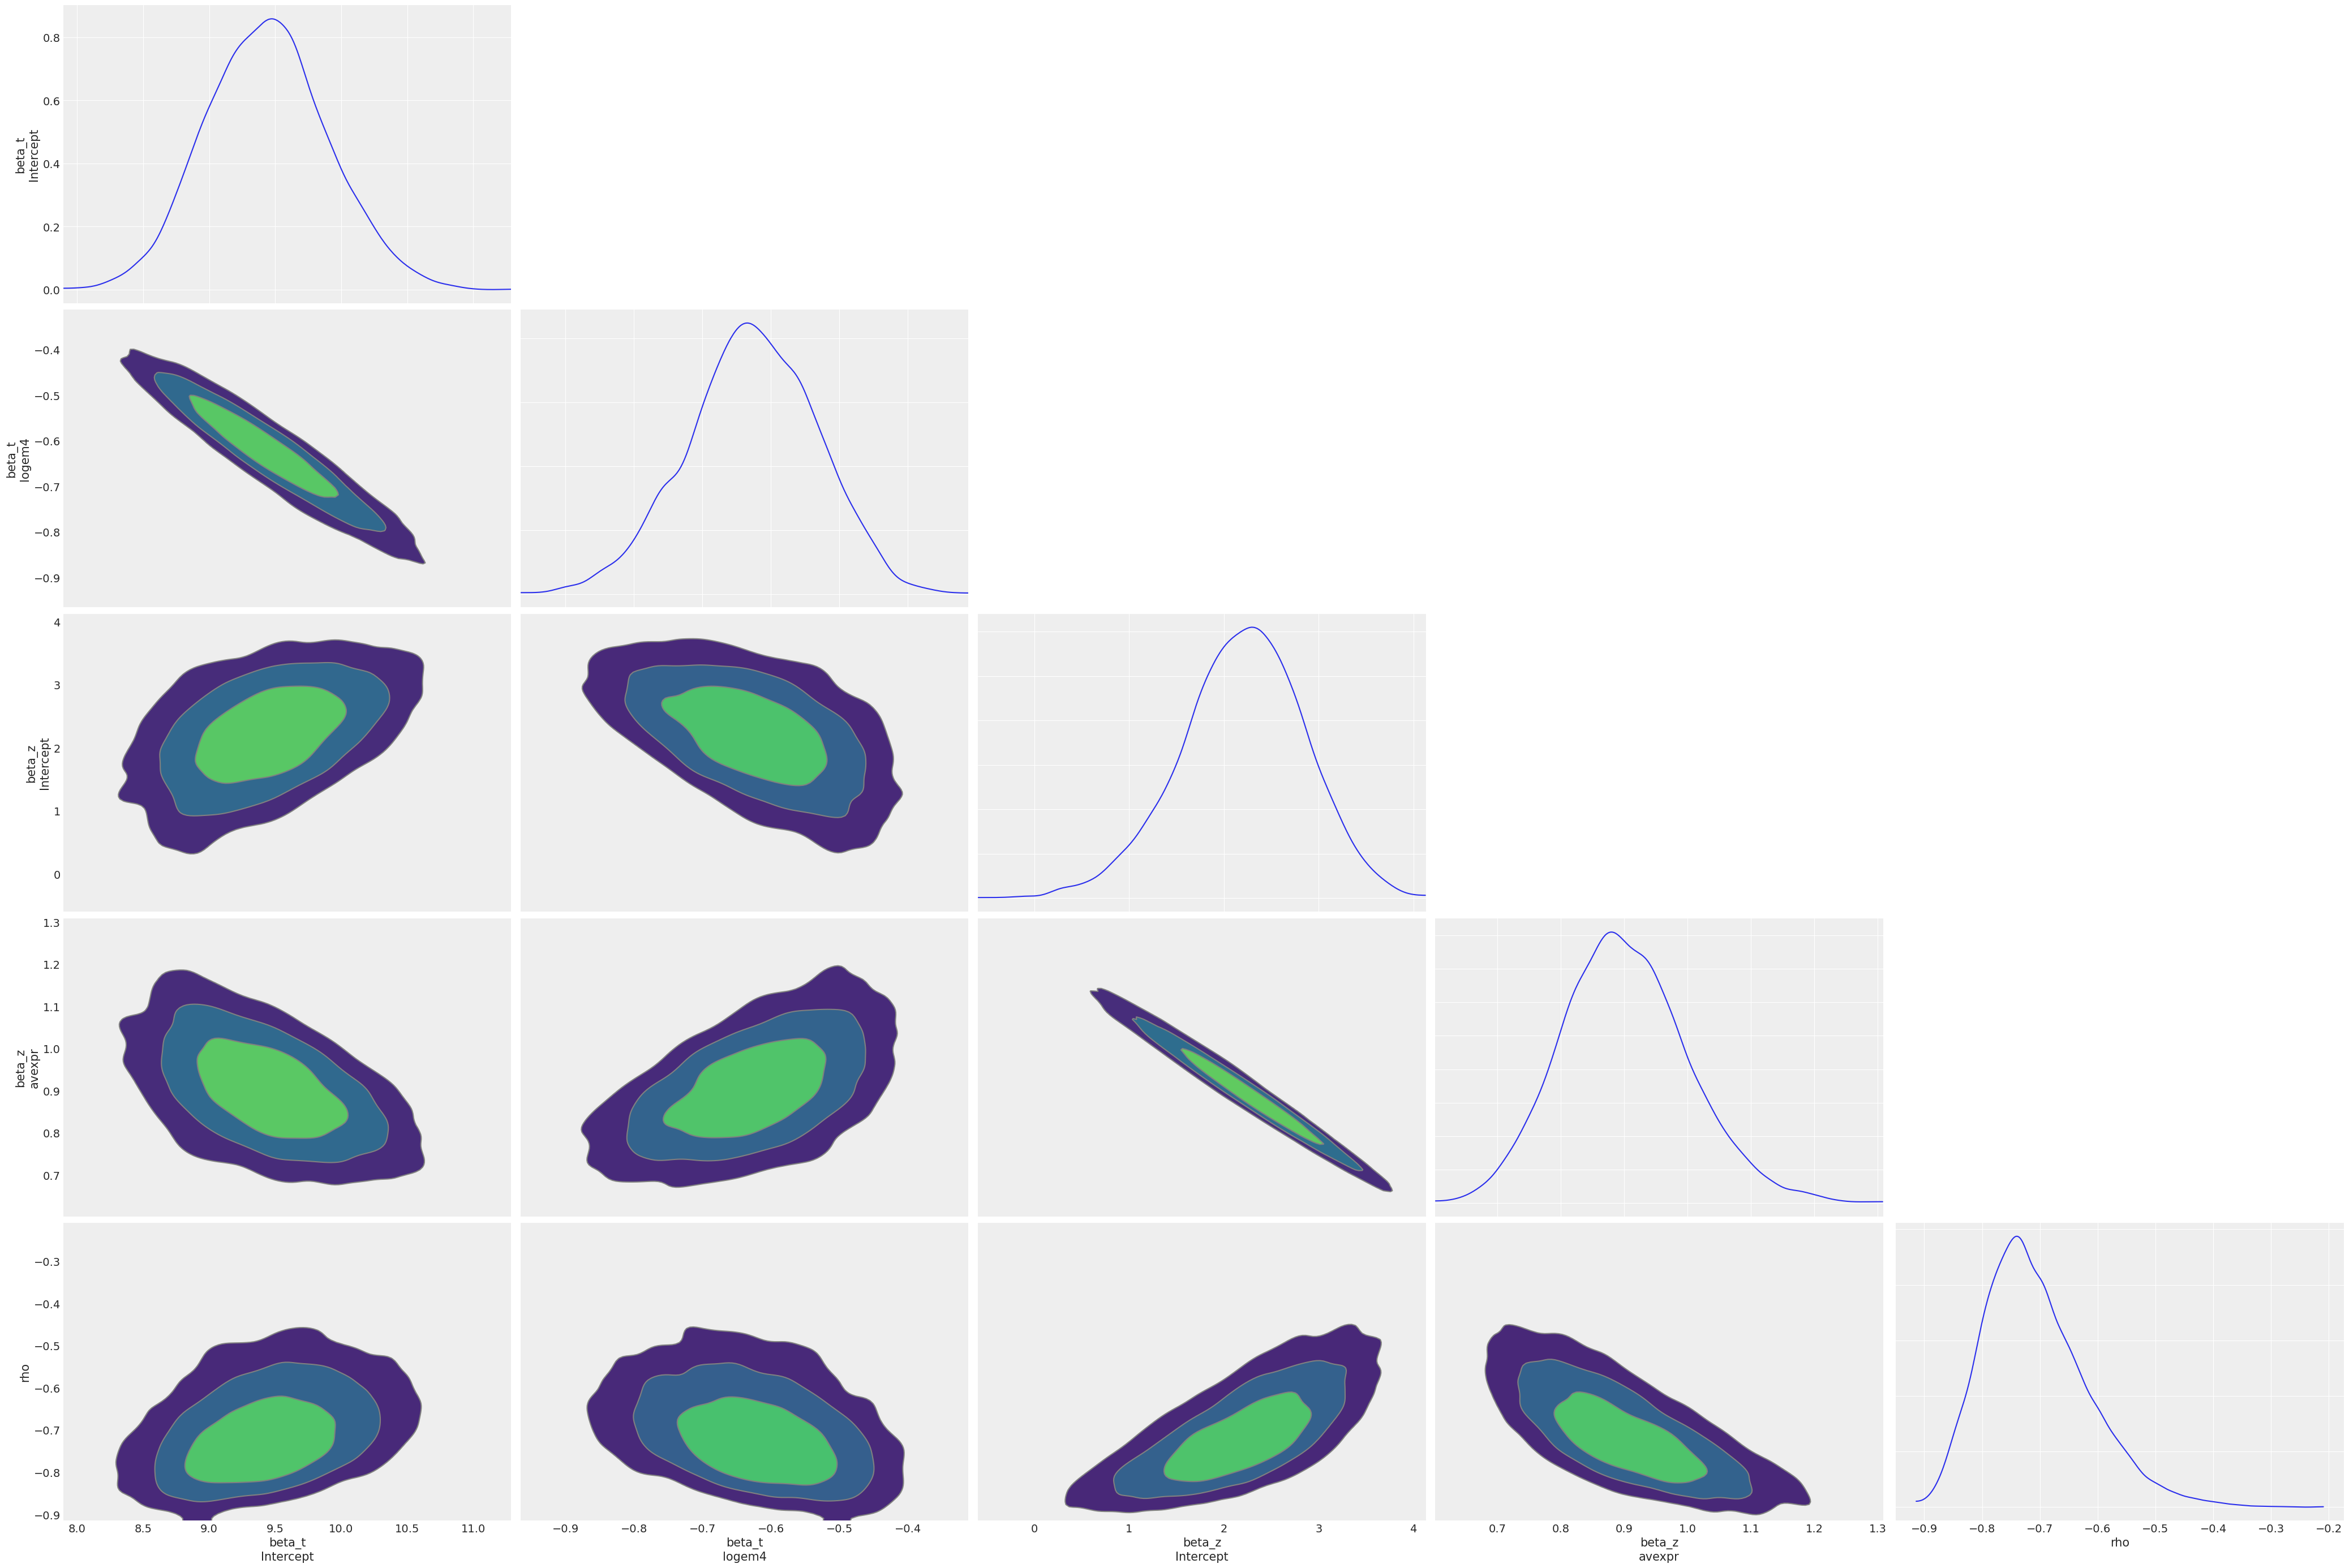

In [7]:
# 1. pull out the pieces of the 2×2 covariance matrix
cov = idata.posterior["cov"]        # dims: (chain, draw, cov_dim_0, cov_dim_1)

σ_uv = cov.sel(cov_dim_0=0, cov_dim_1=1)       # off‑diagonal element
σ_u2 = cov.sel(cov_dim_0=0, cov_dim_1=0)       # variance of u
σ_v2 = cov.sel(cov_dim_0=1, cov_dim_1=1)       # variance of v

# 2. turn it into the correlation ρ
rho = σ_uv / (σ_u2**0.5 * σ_v2**0.5)

# 3. store it inside the InferenceData so ArviZ can see it
idata.posterior["rho"] = rho               # or idata = idata.assign(rho=rho)

# 
az.plot_pair(
    idata,
    var_names=["beta_t", "beta_z", "rho"],
    kind="kde",
    marginals=True,
    divergences=True,
)


In [2]:
# Define individual prior scenarios with complete structure
scenario_01 = {
    "mus": [0, 0],  # beta_t prior N(0,1), let CausalPy use default for beta_z
    "sigmas": [1, 1],     # Default sigma values
    "eta": 2,             # Default eta for LKJ prior
    "lkj_sd": 1,          # Default LKJ standard deviation
}

scenario_05 = {
    "mus": [0, 0],  # beta_t prior N(0,5), let CausalPy use default for beta_z
    "sigmas": [1, 1],     # Default sigma values
    "eta": 2,             # Default eta for LKJ prior
    "lkj_sd": 1,          # Default LKJ standard deviation
}

# For batch processing with ajr_priorfac
scenarios = [
    {"__label__": "N01", "beta_t": pm.Normal.dist(0, 1)},
    {"__label__": "N05", "beta_t": pm.Normal.dist(0, 5)},
]

In [ ]:

# Run with a single scenario at a time using ajr.run()
iv_N01 = ajr.run(priors=scenario_01, baseline_only=True, draws=2000, tune=1001, chains=4, cores=4, covariates=None, data_path=r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta", netcdf_path="ajr_iv_posterior_01.nc")

idata = az.from_netcdf("ajr_iv_posterior_01.nc")
az.plot_trace(idata, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata, var_names=["beta_z"], hdi_prob=0.95)




c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...


KeyboardInterrupt: 

Observed logpgp95 mean: 8.142
Predicted logpgp95 mean: 6.304
Observed logpgp95 std: 1.052
Predicted logpgp95 std: 0.395


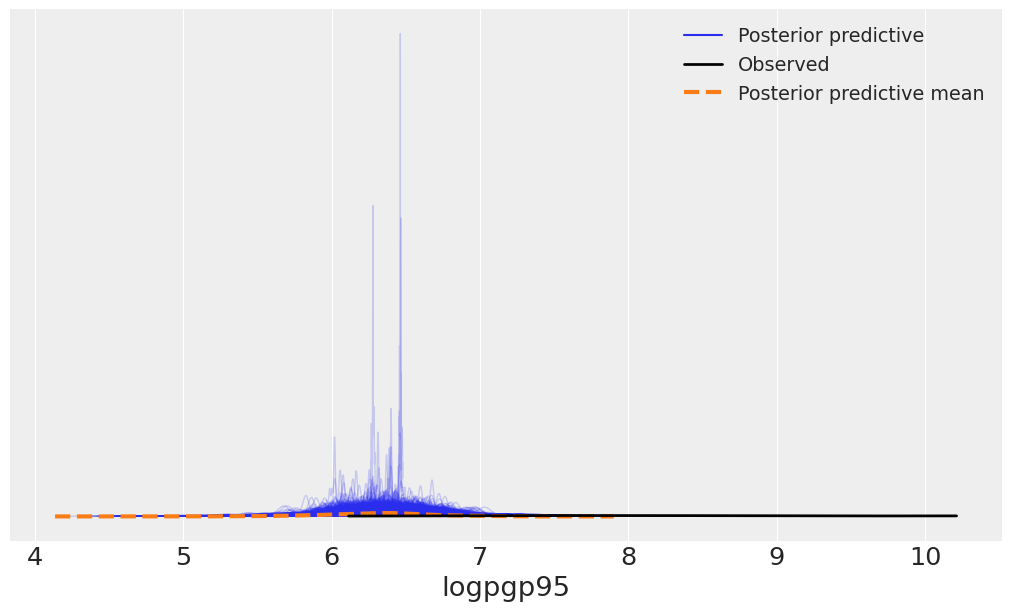

In [ ]:
# Create proper posterior predictive data and use az.plot_ppc
import xarray as xr

# Extract structural equation predictions (logpgp95)
structural_preds = idata.posterior['mu'].isel(mu_dim_1=1)  # logpgp95 predictions

# Get observed logpgp95 values
df_ajr = pd.read_stata(r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta")
df_ajr = df_ajr.dropna(subset=['logem4', 'logpgp95', 'avexpr'])  # Same filtering as in ajr module
observed_logpgp95 = df_ajr['logpgp95'].values

# Add the logpgp95 predictions to posterior_predictive group
idata.posterior_predictive = idata.posterior_predictive.assign(
    logpgp95=structural_preds.rename(mu_dim_0='logpgp95_dim_0')
)

# Add the observed logpgp95 data to observed_data group
observed_da = xr.DataArray(
    observed_logpgp95, 
    dims=['logpgp95_dim_0'],
    coords={'logpgp95_dim_0': range(len(observed_logpgp95))}
)
idata.observed_data = idata.observed_data.assign(logpgp95=observed_da)

# Remove likelihood from both groups to avoid confusion
idata.posterior_predictive = idata.posterior_predictive.drop_vars('likelihood')
idata.observed_data = idata.observed_data.drop_vars('likelihood')

# Now use az.plot_ppc with proper data - specify only logpgp95
az.plot_ppc(
    idata,
    data_pairs={"logpgp95": "logpgp95"},
    var_names=["logpgp95"],  # Only plot logpgp95, not likelihood
    figsize=(10, 6),
)

print(f"Observed logpgp95 mean: {observed_logpgp95.mean():.3f}")
print(f"Predicted logpgp95 mean: {structural_preds.mean().values:.3f}")
print(f"Observed logpgp95 std: {observed_logpgp95.std():.3f}")
print(f"Predicted logpgp95 std: {structural_preds.std().values:.3f}")

In [9]:

iv2 = ajr.run(baseline_only=True, draws=2000, tune=1000, chains=4, cores=4, covariates=['asia', 'africa', 'other_cont', 'lat_abst'], data_path=r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta", netcdf_path="ajr_iv_posterior2.nc")

c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 139 seconds.
Sampling: [likelihood]


Output()

                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_z[Intercept]   2.062  0.825   0.472    3.542      0.016    0.011   
beta_z[avexpr]      1.006  0.130   0.756    1.242      0.003    0.002   
beta_z[asia]       -0.977  0.340  -1.634   -0.366      0.005    0.004   
beta_z[africa]     -0.497  0.257  -0.968   -0.008      0.004    0.003   
beta_z[other_cont] -0.850  0.494  -1.755    0.080      0.007    0.005   
beta_z[lat_abst]   -0.955  0.655  -2.182    0.254      0.010    0.007   
beta_t[Intercept]   7.852  0.499   6.884    8.749      0.008    0.006   
beta_t[logem4]     -0.369  0.099  -0.578   -0.201      0.002    0.001   
beta_t[asia]        0.461  0.412  -0.270    1.280      0.006    0.005   
beta_t[africa]     -0.227  0.335  -0.860    0.393      0.005    0.003   
beta_t[other_cont]  1.040  0.574  -0.051    2.099      0.007    0.006   
beta_t[lat_abst]    2.022  0.717   0.682    3.382      0.009    0.008   

                    ess_bulk  ess_tail  r_hat  
be

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


<Axes: xlabel='likelihood'>

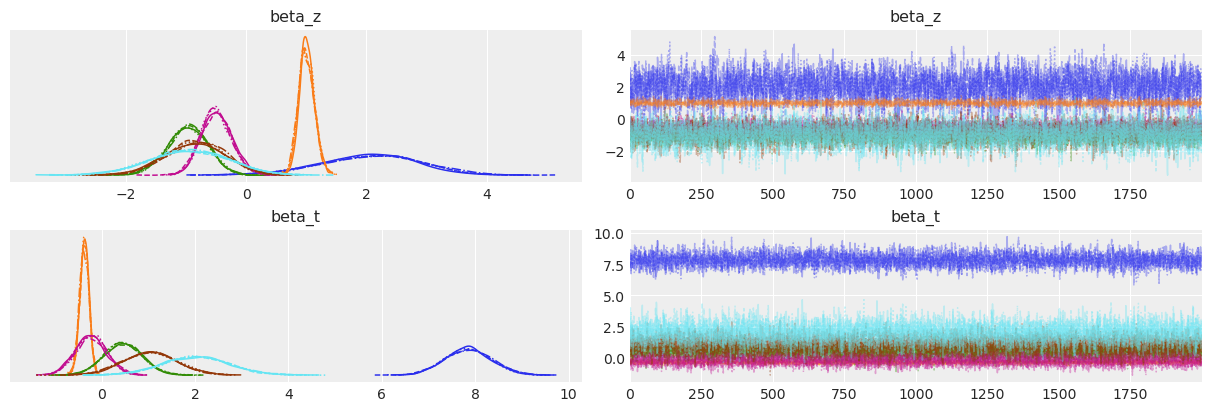

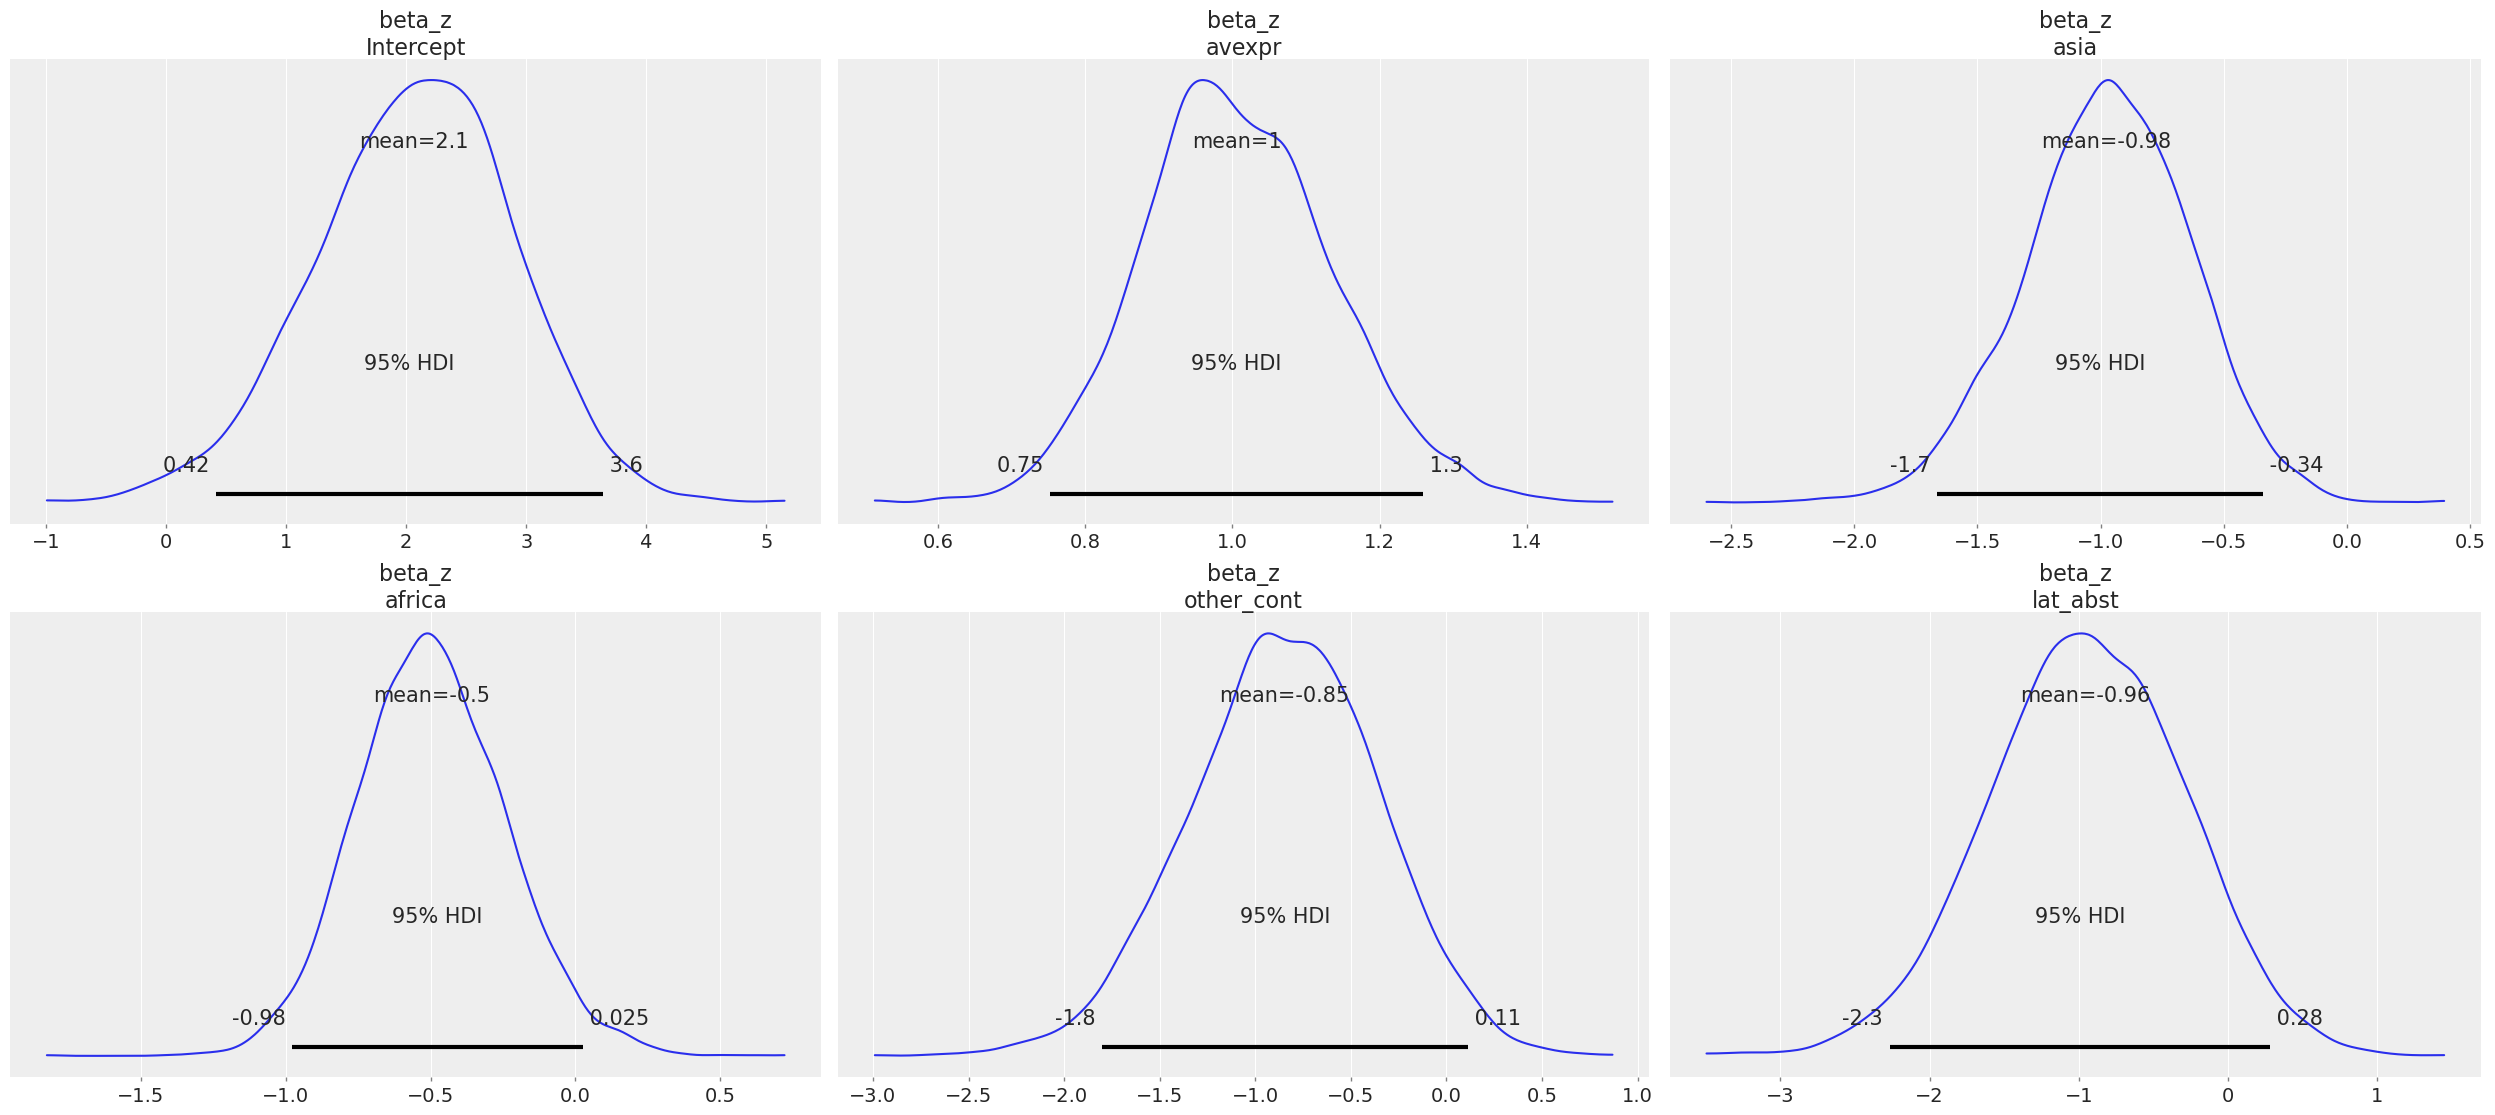

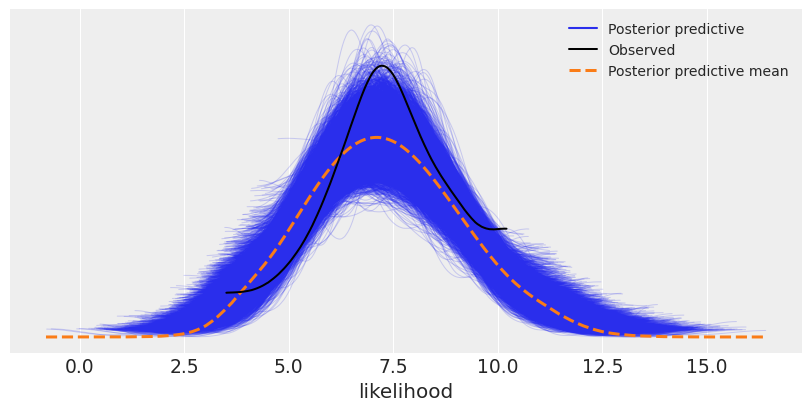

In [ ]:
idata2 = az.from_netcdf("ajr_iv_posterior2.nc")
az.plot_trace(idata2, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata2, var_names=["beta_z"], hdi_prob=0.95)



β_z components: [np.str_('Intercept'), np.str_('avexpr'), np.str_('asia'), np.str_('africa'), np.str_('other_cont'), np.str_('lat_abst')]
β_t components: [np.str_('Intercept'), np.str_('logem4'), np.str_('asia'), np.str_('africa'), np.str_('other_cont'), np.str_('lat_abst')]


C:\Users\B375471\AppData\Local\Temp\ipykernel_5344\2555296892.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


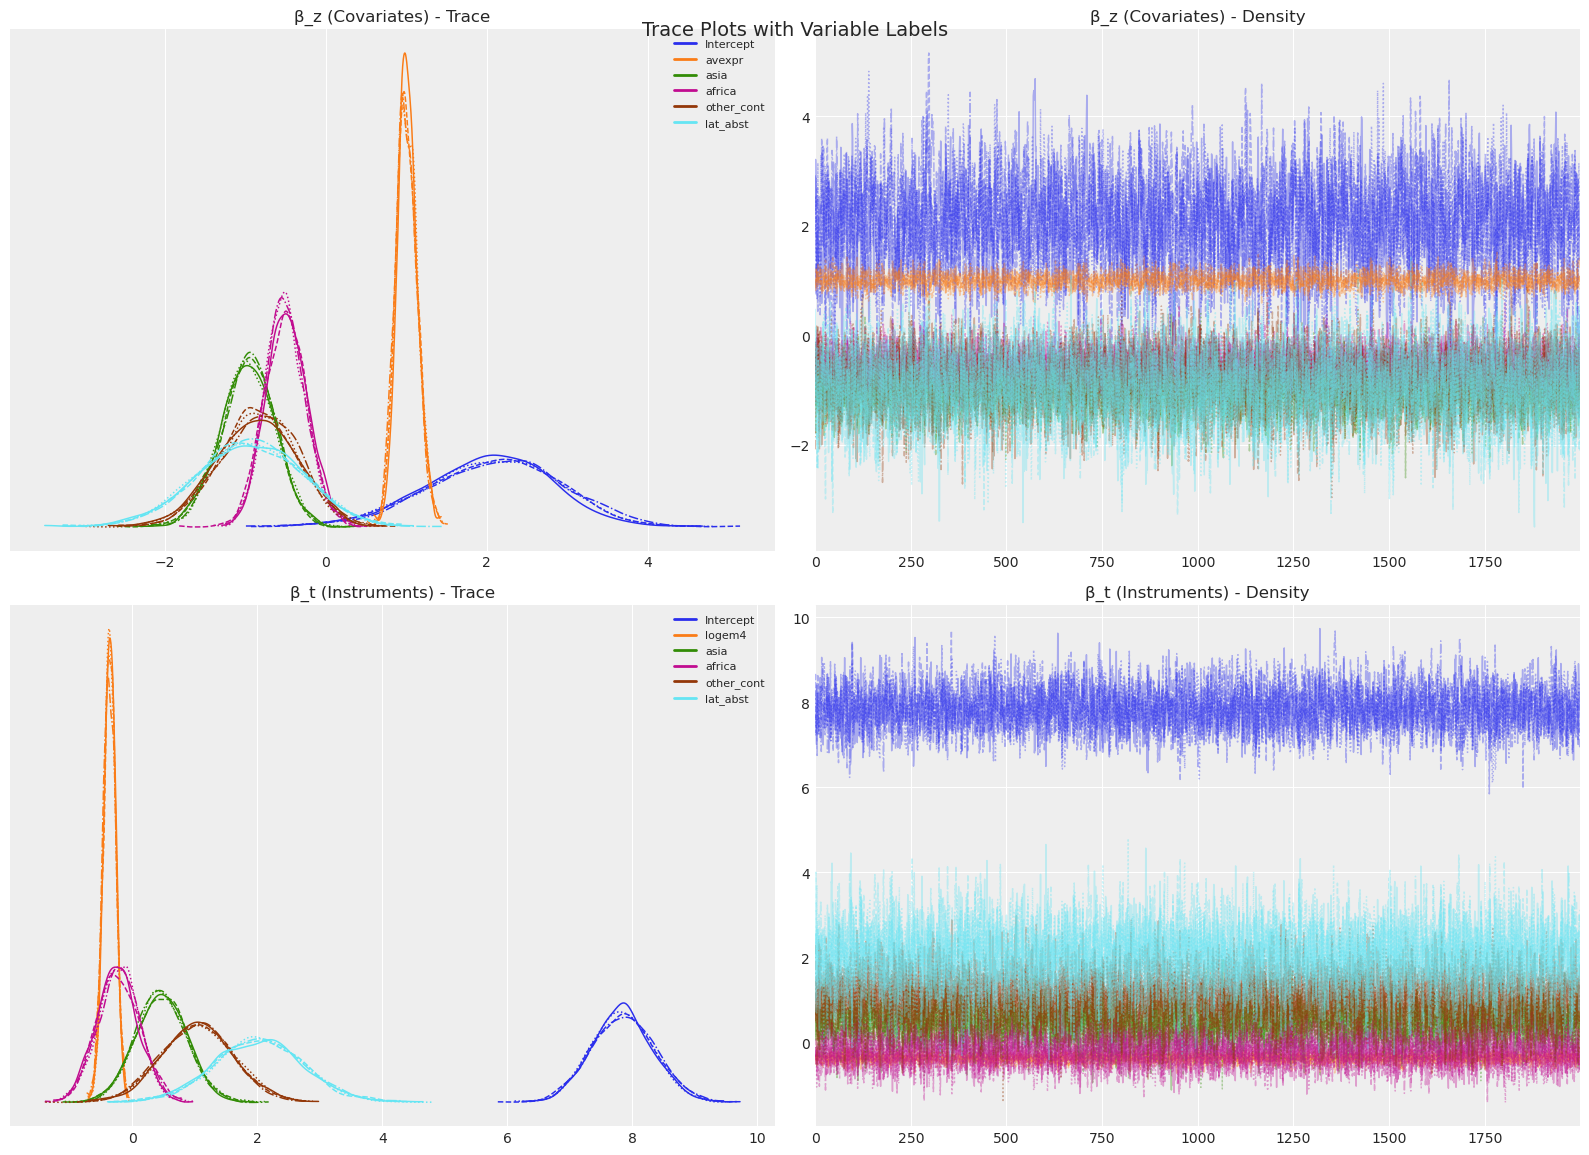

In [11]:
# Same trace plot as above but with variable labels added
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
idata2 = az.from_netcdf("ajr_iv_posterior2.nc")

# Get the coordinate labels
beta_z_coords = list(idata2.posterior.coords['covariates'].values)
beta_t_coords = list(idata2.posterior.coords['instruments'].values)

print("β_z components:", beta_z_coords)
print("β_t components:", beta_t_coords)

# Create the trace plot with enhanced labeling
axes = az.plot_trace(idata2, var_names=["beta_z", "beta_t"], figsize=(16, 12))

# Get the figure and add title
fig = axes.flat[0].figure
fig.suptitle("Trace Plots with Variable Labels", fontsize=14, y=0.95)

# Get default color cycle for mapping
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Add legends to each subplot with color mapping
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        if j == 0:  # Left column (trace plots)
            if i == 0:  # beta_z
                # Create legend entries for beta_z components
                legend_elements = [plt.Line2D([0], [0], color=colors[k % len(colors)], 
                                            lw=2, label=f'{coord}') 
                                 for k, coord in enumerate(beta_z_coords)]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
                ax.set_title('β_z (Covariates) - Trace', fontsize=12)
            elif i == 1:  # beta_t  
                # Create legend entries for beta_t components
                legend_elements = [plt.Line2D([0], [0], color=colors[k % len(colors)], 
                                            lw=2, label=f'{coord}') 
                                 for k, coord in enumerate(beta_t_coords)]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
                ax.set_title('β_t (Instruments) - Trace', fontsize=12)
        else:  # Right column (density plots)
            if i == 0:
                ax.set_title('β_z (Covariates) - Density', fontsize=12)
            elif i == 1:
                ax.set_title('β_t (Instruments) - Density', fontsize=12)

plt.tight_layout()
plt.show()